In [1]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ========== Paths / constants ==========
# Supports running notebook from either repo root (.) or new/.
CWD = Path(".").resolve()
if (CWD / "vlm_output").exists() and (CWD / "gt.csv").exists():
    NEW_ROOT = CWD
    DATA_ROOT = CWD.parent / "data"
elif (CWD / "new" / "vlm_output").exists() and (CWD / "new" / "gt.csv").exists():
    NEW_ROOT = CWD / "new"
    DATA_ROOT = CWD / "data"
else:
    # fallback assumes current working directory is repository root
    NEW_ROOT = CWD / "new"
    DATA_ROOT = CWD / "data"

VLM_OUTPUT_ROOT = NEW_ROOT / "vlm_output"
GT_PATH = NEW_ROOT / "gt.csv"
SPLIT_PATH = DATA_ROOT / "participant_stratified_groupkfold_split_seed42.csv"
BOOTSTRAP_PATH = DATA_ROOT / "bootstrap_indices.npz"

FIELDS = [
    "speed",
    "assistive_device",
    "imbalance",
    "gait_deviation",
    "deviation_outside_walkway",
    "fga_score",
]

PAIR_RE = re.compile(r"\b([a-zA-Z_]+)\b\s*:\s*([-+]?\d+(?:\.\d+)?)")
CLIPS_RE = re.compile(r"clips_fps_(?P<fps>[-+]?\d+(?:\.\d+)?)_length_(?P<length>[-+]?\d+(?:\.\d+)?)$")

# Strict key-based parser per field (wrong format => discarded).
FIELD_PATTERNS = {
    f: re.compile(rf"\b{re.escape(f)}\b\s*:\s*([-+]?\d+(?:\.\d+)?)")
    for f in FIELDS
}

np.set_printoptions(suppress=True)
pd.set_option("display.max_colwidth", 100)

print("Configured paths:")
print(f"- VLM_OUTPUT_ROOT: {VLM_OUTPUT_ROOT}")
print(f"- GT_PATH:         {GT_PATH}")
print(f"- SPLIT_PATH:      {SPLIT_PATH}")
print(f"- BOOTSTRAP_PATH:  {BOOTSTRAP_PATH}")

Configured paths:
- VLM_OUTPUT_ROOT: C:\Users\kerry\ucsf\new\vlm_output
- GT_PATH:         C:\Users\kerry\ucsf\new\gt.csv
- SPLIT_PATH:      C:\Users\kerry\ucsf\data\participant_stratified_groupkfold_split_seed42.csv
- BOOTSTRAP_PATH:  C:\Users\kerry\ucsf\data\bootstrap_indices.npz


In [2]:
# ========= Helpers: parsing, loading, evaluation =========

def mean(vals: Iterable[float]) -> float:
    vals = list(vals)
    return float(sum(vals) / len(vals)) if vals else float("nan")


def norm_sample_id(raw: str) -> str:
    s = str(raw).strip()
    if not s:
        raise ValueError("empty sample id")
    if "_" in s:
        left, right = s.split("_", 1)
        return f"{int(left)}_{int(right)}"
    return str(int(s))


def sample_id_to_participant_id(sample_id: str) -> str:
    sid = norm_sample_id(sample_id)
    left = int(sid.split("_", 1)[0])
    return f"BW-{left:04d}"


def extract_sample_id_from_folder_name(name: str) -> str:
    m = re.match(r"^(\d+)_(\d+)$", name)
    if m:
        return f"{int(m.group(1))}_{int(m.group(2))}"
    nums = re.findall(r"\d+", name)
    if len(nums) >= 2:
        return f"{int(nums[0])}_{int(nums[1])}"
    raise ValueError(f"Cannot parse sample id from folder: {name}")


def parse_scores_from_text(text: str) -> Dict[str, float] | None:
    """
    Strict-format parser:
    return None if any required field is missing.
    """
    out: Dict[str, float] = {}
    for f in FIELDS:
        m = FIELD_PATTERNS[f].search(text)
        if not m:
            return None
        out[f] = float(m.group(1))
    return out


def load_gt_csv(path: Path) -> tuple[pd.DataFrame, Dict[str, Dict[str, float]], Dict[str, List[str]]]:
    df = pd.read_csv(path)
    need = ["id"] + FIELDS
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"GT missing columns: {missing}")

    df = df.copy()
    df["id"] = df["id"].map(norm_sample_id)

    gt_map: Dict[str, Dict[str, float]] = {}
    participant_to_sample_ids: Dict[str, List[str]] = {}

    for _, row in df.iterrows():
        sid = row["id"]
        gt_map[sid] = {f: float(row[f]) if pd.notna(row[f]) else float("nan") for f in FIELDS}
        pid = sample_id_to_participant_id(sid)
        participant_to_sample_ids.setdefault(pid, []).append(sid)

    return df, gt_map, participant_to_sample_ids


@dataclass
class ClipParseStats:
    total_outputs: int
    usable_outputs: int
    sample_dirs_seen: int
    sample_dirs_with_usable: int

    @property
    def usable_pct(self) -> float:
        if self.total_outputs == 0:
            return float("nan")
        return float(self.usable_outputs / self.total_outputs)


def collect_sample_predictions(clips_root: Path, max_clips_per_sample: int = 3) -> tuple[Dict[str, Dict[str, float]], ClipParseStats]:
    """
    Returns per-sample averaged predictions.
    If a clip output has wrong format, that clip is discarded.
    If all clips for a sample are wrong, that sample is discarded.
    """
    pred_avg_by_sample: Dict[str, Dict[str, float]] = {}

    total_outputs = 0
    usable_outputs = 0
    sample_dirs_seen = 0
    sample_dirs_with_usable = 0

    if not clips_root.exists():
        return pred_avg_by_sample, ClipParseStats(0, 0, 0, 0)

    for sample_dir in sorted([p for p in clips_root.iterdir() if p.is_dir()]):
        sample_dirs_seen += 1

        try:
            sample_id = extract_sample_id_from_folder_name(sample_dir.name)
        except Exception:
            continue

        txts = sorted(sample_dir.glob("*.txt"))[:max_clips_per_sample]
        if not txts:
            continue

        parsed = []
        for txt in txts:
            total_outputs += 1
            text = txt.read_text(encoding="utf-8", errors="ignore")
            scores = parse_scores_from_text(text)
            if scores is None:
                continue
            usable_outputs += 1
            parsed.append(scores)

        if not parsed:
            continue

        sample_dirs_with_usable += 1
        pred_avg_by_sample[sample_id] = {f: mean(d[f] for d in parsed) for f in FIELDS}

    stats = ClipParseStats(
        total_outputs=total_outputs,
        usable_outputs=usable_outputs,
        sample_dirs_seen=sample_dirs_seen,
        sample_dirs_with_usable=sample_dirs_with_usable,
    )
    return pred_avg_by_sample, stats


def compute_metrics_for_sample_ids(sample_ids: List[str], pred_map: Dict[str, Dict[str, float]], gt_map: Dict[str, Dict[str, float]]) -> Dict[str, object]:
    mae_by_field: Dict[str, float] = {}
    mse_by_field: Dict[str, float] = {}
    n_by_field: Dict[str, int] = {}

    all_abs: List[float] = []
    all_sq: List[float] = []

    for f in FIELDS:
        abs_errs = []
        sq_errs = []
        for sid in sample_ids:
            if sid not in pred_map or sid not in gt_map:
                continue
            gt_val = gt_map[sid][f]
            if math.isnan(gt_val):
                continue
            err = float(pred_map[sid][f]) - float(gt_val)
            abs_errs.append(abs(err))
            sq_errs.append(err * err)
        mae_by_field[f] = mean(abs_errs)
        mse_by_field[f] = mean(sq_errs)
        n_by_field[f] = len(abs_errs)
        all_abs.extend(abs_errs)
        all_sq.extend(sq_errs)

    scored_ids = sum(1 for sid in sample_ids if sid in pred_map and sid in gt_map)

    return {
        "mae_by_field": mae_by_field,
        "mse_by_field": mse_by_field,
        "n_by_field": n_by_field,
        "overall_mae": mean(all_abs),
        "overall_mse": mean(all_sq),
        "n_pairs": len(all_abs),
        "n_scored_ids": scored_ids,
    }


def nanmean(vals: Iterable[float]) -> float:
    arr = np.array(list(vals), dtype=float)
    return float(np.nanmean(arr)) if arr.size else float("nan")


def fold_average_metrics(fold_metrics: Dict[str, Dict[str, object]]) -> Dict[str, object]:
    fold_names = sorted(fold_metrics.keys())

    out_mae_field = {}
    out_mse_field = {}
    out_n_field = {}

    for f in FIELDS:
        out_mae_field[f] = nanmean(fold_metrics[k]["mae_by_field"][f] for k in fold_names)
        out_mse_field[f] = nanmean(fold_metrics[k]["mse_by_field"][f] for k in fold_names)
        out_n_field[f] = int(sum(fold_metrics[k]["n_by_field"][f] for k in fold_names))

    return {
        "mae_by_field": out_mae_field,
        "mse_by_field": out_mse_field,
        "overall_mae": nanmean(fold_metrics[k]["overall_mae"] for k in fold_names),
        "overall_mse": nanmean(fold_metrics[k]["overall_mse"] for k in fold_names),
        "n_pairs_total": int(sum(fold_metrics[k]["n_pairs"] for k in fold_names)),
        "n_scored_ids_total": int(sum(fold_metrics[k]["n_scored_ids"] for k in fold_names)),
        "n_by_field_total": out_n_field,
    }


def discover_clip_roots(vlm_root: Path) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for setup_dir in sorted([p for p in vlm_root.iterdir() if p.is_dir()]):
        for clips_root in sorted([p for p in setup_dir.glob("clips_fps_*_length_*") if p.is_dir()]):
            m = CLIPS_RE.match(clips_root.name)
            if not m:
                continue
            rows.append(
                {
                    "setup_name": setup_dir.name,
                    "clips_name": clips_root.name,
                    "setup_id": f"{setup_dir.name}/{clips_root.name}",
                    "clips_root": clips_root,
                    "fps": float(m.group("fps")),
                    "length": float(m.group("length")),
                }
            )
    return rows


def evaluate_clip_root(
    clips_root: Path,
    fold_to_sample_ids: Dict[str, List[str]],
    gt_map: Dict[str, Dict[str, float]],
) -> Dict[str, object]:
    pred_map, parse_stats = collect_sample_predictions(clips_root)

    per_fold: Dict[str, Dict[str, object]] = {}
    for fold_name, sample_ids in fold_to_sample_ids.items():
        per_fold[fold_name] = compute_metrics_for_sample_ids(sample_ids, pred_map, gt_map)

    fold_avg = fold_average_metrics(per_fold)

    return {
        "pred_map": pred_map,
        "parse_stats": parse_stats,
        "per_fold": per_fold,
        "fold_avg": fold_avg,
    }


def bootstrap_metrics_for_clip_root(
    clips_root: Path,
    gt_map: Dict[str, Dict[str, float]],
    split_df: pd.DataFrame,
    participant_to_sample_ids: Dict[str, List[str]],
    boot_indices: Dict[str, np.ndarray],
) -> Dict[str, object]:
    pred_map, _ = collect_sample_predictions(clips_root)

    row_participants = split_df["participant_id"].astype(str).tolist()

    per_fold_boot_mae = {f: [] for f in FIELDS}
    per_fold_boot_mse = {f: [] for f in FIELDS}
    per_fold_boot_overall_mae: Dict[str, np.ndarray] = {}
    per_fold_boot_overall_mse: Dict[str, np.ndarray] = {}

    for k in range(5):
        fold_name = f"fold_{k}"
        if fold_name not in boot_indices:
            raise KeyError(f"Missing bootstrap key: {fold_name}")

        mat = boot_indices[fold_name]  # (B, n_fold), absolute row indices in split csv
        B = mat.shape[0]

        fold_overall_mae = np.full(B, np.nan, dtype=float)
        fold_overall_mse = np.full(B, np.nan, dtype=float)

        field_mae_samples = {f: np.full(B, np.nan, dtype=float) for f in FIELDS}
        field_mse_samples = {f: np.full(B, np.nan, dtype=float) for f in FIELDS}

        for b in range(B):
            sampled_rows = mat[b]
            sampled_sample_ids: List[str] = []
            for row_idx in sampled_rows:
                pid = row_participants[int(row_idx)]
                sampled_sample_ids.extend(participant_to_sample_ids.get(pid, []))

            m = compute_metrics_for_sample_ids(sampled_sample_ids, pred_map, gt_map)
            fold_overall_mae[b] = m["overall_mae"]
            fold_overall_mse[b] = m["overall_mse"]
            for f in FIELDS:
                field_mae_samples[f][b] = m["mae_by_field"][f]
                field_mse_samples[f][b] = m["mse_by_field"][f]

        per_fold_boot_overall_mae[fold_name] = fold_overall_mae
        per_fold_boot_overall_mse[fold_name] = fold_overall_mse
        for f in FIELDS:
            per_fold_boot_mae[f].append(field_mae_samples[f])
            per_fold_boot_mse[f].append(field_mse_samples[f])

    # Fold-average bootstrap distribution: for each b, average across folds.
    # Assumes all folds were generated with same B (as in bootstrap.py).
    any_fold = next(iter(per_fold_boot_overall_mae))
    B = per_fold_boot_overall_mae[any_fold].shape[0]

    overall_mae_dist = np.array(
        [nanmean(per_fold_boot_overall_mae[f"fold_{k}"][b] for k in range(5)) for b in range(B)],
        dtype=float,
    )
    overall_mse_dist = np.array(
        [nanmean(per_fold_boot_overall_mse[f"fold_{k}"][b] for k in range(5)) for b in range(B)],
        dtype=float,
    )

    mae_by_field_dist: Dict[str, np.ndarray] = {}
    mse_by_field_dist: Dict[str, np.ndarray] = {}

    for f in FIELDS:
        stacked_mae = np.vstack(per_fold_boot_mae[f])  # (5, B)
        stacked_mse = np.vstack(per_fold_boot_mse[f])  # (5, B)
        mae_by_field_dist[f] = np.nanmean(stacked_mae, axis=0)
        mse_by_field_dist[f] = np.nanmean(stacked_mse, axis=0)

    return {
        "overall_mae_dist": overall_mae_dist,
        "overall_mse_dist": overall_mse_dist,
        "mae_by_field_dist": mae_by_field_dist,
        "mse_by_field_dist": mse_by_field_dist,
    }


def summarize_bootstrap(arr: np.ndarray) -> tuple[float, float, float]:
    a = np.asarray(arr, dtype=float)
    return float(np.nanmean(a)), float(np.nanpercentile(a, 2.5)), float(np.nanpercentile(a, 97.5))


print("Helper functions loaded.")

Helper functions loaded.


In [3]:
# ========= Load GT, fold split, and bootstrap indices =========

if not GT_PATH.exists():
    raise FileNotFoundError(f"GT file not found: {GT_PATH}")
if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"Fold split file not found: {SPLIT_PATH}")

GT_DF, GT_MAP, PARTICIPANT_TO_SAMPLE_IDS = load_gt_csv(GT_PATH)
SPLIT_DF = pd.read_csv(SPLIT_PATH)

need_split_cols = ["participant_id", "split"]
missing = [c for c in need_split_cols if c not in SPLIT_DF.columns]
if missing:
    raise ValueError(f"Split CSV missing columns: {missing}")

# Build fold -> sample_id list from participant-level split.
FOLD_TO_SAMPLE_IDS: Dict[str, List[str]] = {}
for k in range(5):
    fold_name = f"fold_{k}"
    pids = SPLIT_DF.loc[SPLIT_DF["split"] == fold_name, "participant_id"].astype(str).tolist()
    fold_sample_ids: List[str] = []
    for pid in pids:
        fold_sample_ids.extend(PARTICIPANT_TO_SAMPLE_IDS.get(pid, []))
    FOLD_TO_SAMPLE_IDS[fold_name] = fold_sample_ids

BOOT_DATA: Dict[str, np.ndarray] | None = None
if BOOTSTRAP_PATH.exists():
    z = np.load(BOOTSTRAP_PATH)
    BOOT_DATA = {f"fold_{k}": z[f"fold_{k}"] for k in range(5)}
    print(f"Loaded bootstrap indices: {BOOTSTRAP_PATH}")
    for k in range(5):
        print(f"- fold_{k} shape: {BOOT_DATA[f'fold_{k}'].shape}")
else:
    print("WARNING: bootstrap_indices.npz not found.")
    print(f"Expected path: {BOOTSTRAP_PATH}")
    print("Bootstrap plots will be skipped until this file is available.")

print("\nGT and fold split summary:")
print(f"- GT rows (sample ids): {len(GT_DF)}")
print(f"- Split rows (participants): {len(SPLIT_DF)}")
for k in range(5):
    f = f"fold_{k}"
    n_participants = int((SPLIT_DF['split'] == f).sum())
    n_samples = len(FOLD_TO_SAMPLE_IDS[f])
    print(f"  {f}: participants={n_participants}, sample_ids_from_gt={n_samples}")

Loaded bootstrap indices: C:\Users\kerry\ucsf\data\bootstrap_indices.npz
- fold_0 shape: (10000, 9)
- fold_1 shape: (10000, 10)
- fold_2 shape: (10000, 9)
- fold_3 shape: (10000, 9)
- fold_4 shape: (10000, 9)

GT and fold split summary:
- GT rows (sample ids): 92
- Split rows (participants): 46
  fold_0: participants=9, sample_ids_from_gt=18
  fold_1: participants=10, sample_ids_from_gt=20
  fold_2: participants=9, sample_ids_from_gt=18
  fold_3: participants=9, sample_ids_from_gt=18
  fold_4: participants=9, sample_ids_from_gt=18


In [4]:
# ========= Evaluate ALL clip setups in vlm_output =========

all_clip_roots = discover_clip_roots(VLM_OUTPUT_ROOT)
if not all_clip_roots:
    raise RuntimeError(f"No clip roots found under: {VLM_OUTPUT_ROOT}")

print(f"Discovered clip roots: {len(all_clip_roots)}")

rows = []
EVAL_CACHE: Dict[str, Dict[str, object]] = {}

for meta in all_clip_roots:
    setup_id = meta["setup_id"]
    clips_root = meta["clips_root"]

    result = evaluate_clip_root(clips_root, FOLD_TO_SAMPLE_IDS, GT_MAP)
    EVAL_CACHE[setup_id] = result

    fold_avg = result["fold_avg"]
    parse_stats: ClipParseStats = result["parse_stats"]

    rows.append(
        {
            "setup_name": meta["setup_name"],
            "clips_name": meta["clips_name"],
            "setup_id": setup_id,
            "clips_root": clips_root,
            "fps": meta["fps"],
            "length": meta["length"],
            "overall_mae": fold_avg["overall_mae"],
            "overall_mse": fold_avg["overall_mse"],
            "mae_by_field": fold_avg["mae_by_field"],
            "mse_by_field": fold_avg["mse_by_field"],
            "usable_pct": parse_stats.usable_pct,
            "usable_outputs": parse_stats.usable_outputs,
            "total_outputs": parse_stats.total_outputs,
            "n_pairs_total": fold_avg["n_pairs_total"],
            "n_scored_ids_total": fold_avg["n_scored_ids_total"],
        }
    )

RESULTS_DF = pd.DataFrame(rows)
RESULTS_DF = RESULTS_DF.sort_values(["overall_mae", "overall_mse", "setup_id"], ascending=[True, True, True]).reset_index(drop=True)

BEST_ROW = RESULTS_DF.iloc[0].to_dict()
BEST_SETUP_ID = BEST_ROW["setup_id"]
BEST_CLIPS_ROOT = BEST_ROW["clips_root"]

print("\nTop setups (fold-avg metrics):")
display(
    RESULTS_DF[
        [
            "setup_id",
            "overall_mae",
            "overall_mse",
            "usable_pct",
            "usable_outputs",
            "total_outputs",
            "n_scored_ids_total",
        ]
    ].head(15)
)

print("\nBest setup selected (min fold-avg overall MAE):")
print(f"- setup_id:    {BEST_SETUP_ID}")
print(f"- overall_mae: {BEST_ROW['overall_mae']:.4f}")
print(f"- overall_mse: {BEST_ROW['overall_mse']:.4f}")
print(f"- usable_pct:  {BEST_ROW['usable_pct']:.3f}")

Discovered clip roots: 25


C:\Users\kerry\AppData\Local\Temp\ipykernel_19684\1275228548.py:178: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(arr)) if arr.size else float("nan")



Top setups (fold-avg metrics):


,setup_id,overall_mae,overall_mse,usable_pct,usable_outputs,total_outputs,n_scored_ids_total
0,llava_l_icl_therapist/clips_fps_8.0_length_2.0,0.266145,0.412626,1.000000,144,144,48
1,llava_l_icl_therapist/clips_fps_1.0_length_16.0,0.415941,0.741582,1.000000,233,233,79
2,llava_l_icl_therapist/clips_fps_2.0_length_8.0,0.415941,0.741582,1.000000,237,237,79
3,llava_l_icl_therapist/clips_fps_4.0_length_4.0,0.415941,0.741582,1.000000,237,237,79
4,intern_l_icl_therapist/clips_fps_4.0_length_4.0,0.488889,0.933333,1.000000,42,42,14
5,llava_l_noicl_therapist/clips_fps_2.0_length_8.0,1.128909,1.649954,1.000000,237,237,79
6,llava_l_noicl_therapist/clips_fps_8.0_length_2.0,1.130458,1.651396,1.000000,237,237,79
7,llava_l_noicl_therapist/clips_fps_1.0_length_16.0,1.130992,1.655278,1.000000,233,233,79
8,llava_l_noicl_therapist/clips_fps_16.0_length_1.0,1.131313,1.649473,1.000000,237,237,79
9,llava_l_noicl_therapist/clips_fps_4.0_length_4.0,1.131313,1.657522,1.000000,237,237,79



Best setup selected (min fold-avg overall MAE):
- setup_id:    llava_l_icl_therapist/clips_fps_8.0_length_2.0
- overall_mae: 0.2661
- overall_mse: 0.4126
- usable_pct:  1.000


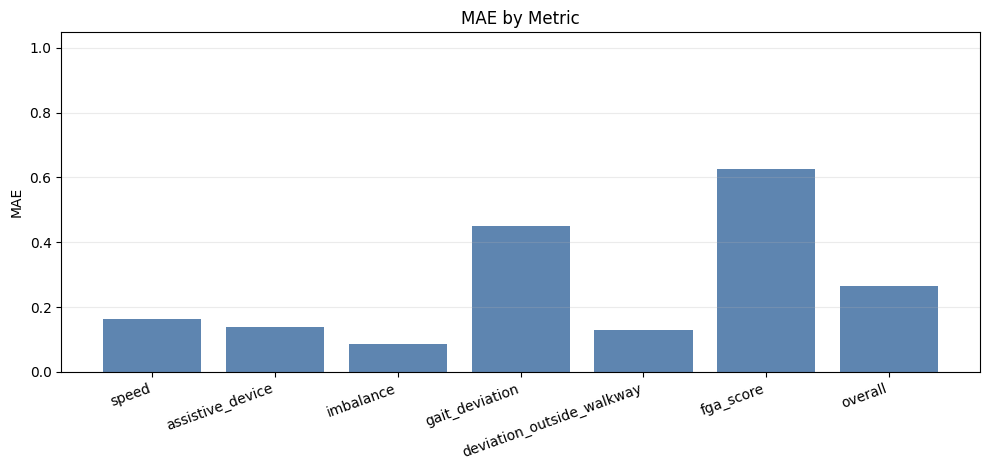

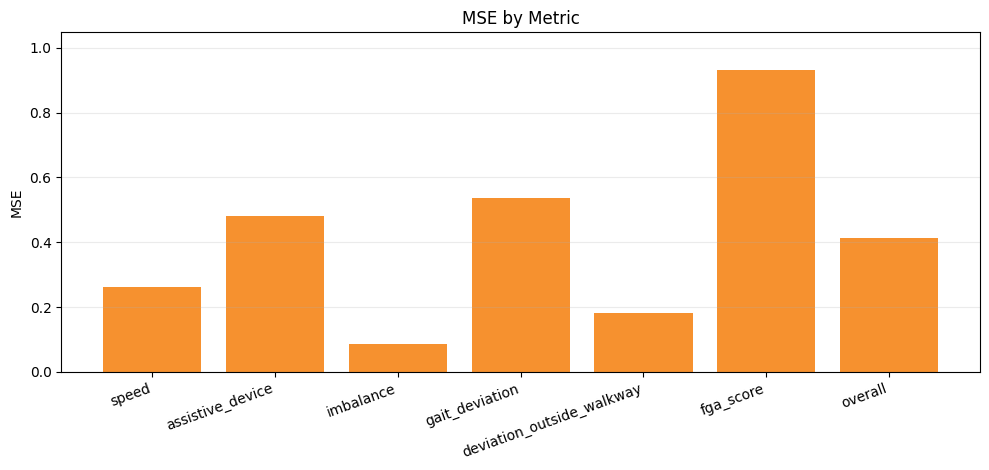

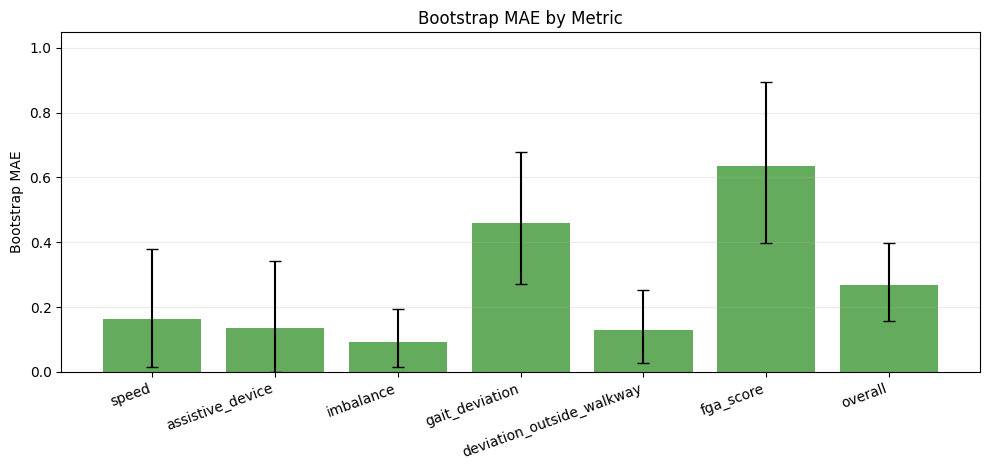

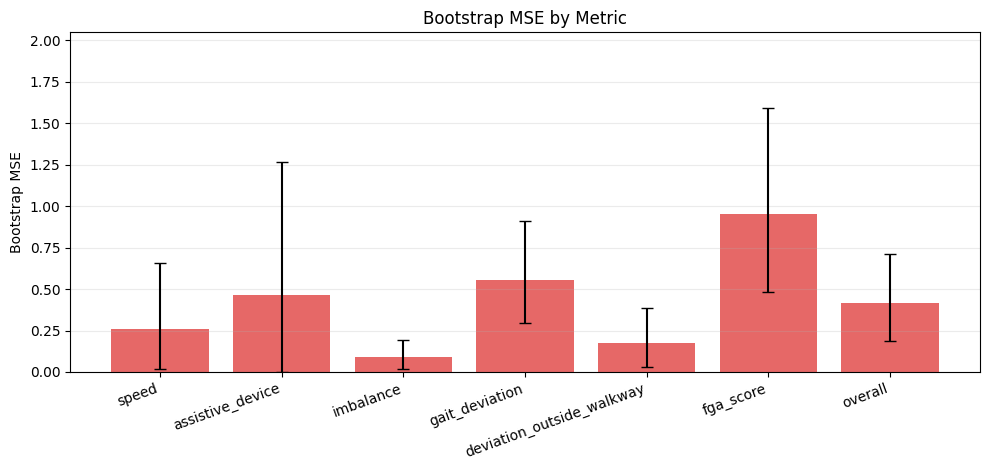

In [5]:
# ========= Plot 1: best setup (4 separate graphs) =========

best_eval = EVAL_CACHE[BEST_SETUP_ID]
best_fold_avg = best_eval["fold_avg"]

labels = FIELDS + ["overall"]
x = np.arange(len(labels))

mae_vals = np.array([best_fold_avg["mae_by_field"][f] for f in FIELDS] + [best_fold_avg["overall_mae"]], dtype=float)
mse_vals = np.array([best_fold_avg["mse_by_field"][f] for f in FIELDS] + [best_fold_avg["overall_mse"]], dtype=float)

boot_mae_vals = np.full(len(labels), np.nan, dtype=float)
boot_mse_vals = np.full(len(labels), np.nan, dtype=float)
boot_mae_ci = np.full((2, len(labels)), np.nan, dtype=float)
boot_mse_ci = np.full((2, len(labels)), np.nan, dtype=float)

if BOOT_DATA is not None:
    BOOT_BEST = bootstrap_metrics_for_clip_root(
        clips_root=BEST_CLIPS_ROOT,
        gt_map=GT_MAP,
        split_df=SPLIT_DF,
        participant_to_sample_ids=PARTICIPANT_TO_SAMPLE_IDS,
        boot_indices=BOOT_DATA,
    )

    for i, f in enumerate(FIELDS):
        m, lo, hi = summarize_bootstrap(BOOT_BEST["mae_by_field_dist"][f])
        boot_mae_vals[i] = m
        boot_mae_ci[0, i] = m - lo
        boot_mae_ci[1, i] = hi - m

        m, lo, hi = summarize_bootstrap(BOOT_BEST["mse_by_field_dist"][f])
        boot_mse_vals[i] = m
        boot_mse_ci[0, i] = m - lo
        boot_mse_ci[1, i] = hi - m

    m, lo, hi = summarize_bootstrap(BOOT_BEST["overall_mae_dist"])
    boot_mae_vals[-1] = m
    boot_mae_ci[0, -1] = m - lo
    boot_mae_ci[1, -1] = hi - m

    m, lo, hi = summarize_bootstrap(BOOT_BEST["overall_mse_dist"])
    boot_mse_vals[-1] = m
    boot_mse_ci[0, -1] = m - lo
    boot_mse_ci[1, -1] = hi - m
else:
    print("Bootstrap file missing -> bootstrap charts will render NaNs.")

shared_ymax = np.nanmax(
    np.concatenate(
        [
            mae_vals,
            mse_vals,
            boot_mae_vals,
            boot_mse_vals,
        ]
    )
)
shared_ymax = max(float(shared_ymax) * 1.1, 0.1)

plt.figure(figsize=(10, 4.8))
plt.bar(x, mae_vals, color="#4C78A8", alpha=0.9)
plt.ylim(0, shared_ymax)
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("MAE")
plt.title(f"MAE by Metric")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.8))
plt.bar(x, mse_vals, color="#F58518", alpha=0.9)
plt.ylim(0, shared_ymax)
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("MSE")
plt.title(f"MSE by Metric")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.8))
plt.bar(x, boot_mae_vals, yerr=boot_mae_ci, capsize=4, color="#54A24B", alpha=0.9)
plt.ylim(0, shared_ymax)
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("Bootstrap MAE")
plt.title(f"Bootstrap MAE by Metric")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.8))
plt.bar(x, boot_mse_vals, yerr=boot_mse_ci, capsize=4, color="#E45756", alpha=0.9)
plt.ylim(0, shared_ymax + 1)
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("Bootstrap MSE")
plt.title(f"Bootstrap MSE by Metric")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

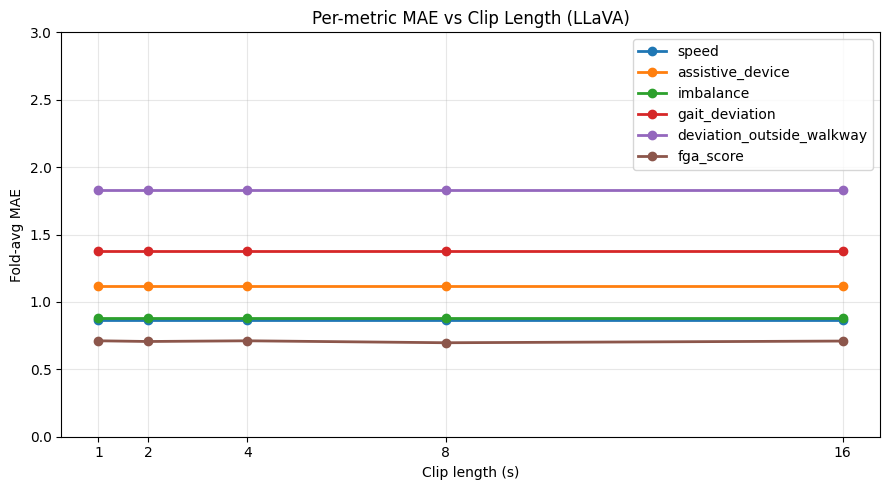

,setup_id,overall_mae,overall_mse,usable_pct
8,llava_l_noicl_therapist/clips_fps_16.0_length_1.0,1.131313,1.649473,1.0
6,llava_l_noicl_therapist/clips_fps_8.0_length_2.0,1.130458,1.651396,1.0
9,llava_l_noicl_therapist/clips_fps_4.0_length_4.0,1.131313,1.657522,1.0
5,llava_l_noicl_therapist/clips_fps_2.0_length_8.0,1.128909,1.649954,1.0
7,llava_l_noicl_therapist/clips_fps_1.0_length_16.0,1.130992,1.655278,1.0


In [6]:
# ========= Plot 2: per-metric MAE vs clip-length (non-icl llava_l) =========

setup_target = "llava_l_noicl_therapist"
sub = RESULTS_DF[RESULTS_DF["setup_name"] == setup_target].copy()

if sub.empty:
    print(f"No rows for setup_name={setup_target}")
else:
    sub = sub.sort_values("length")
    lengths = sub["length"].tolist()

    plt.figure(figsize=(9, 5))
    for f in FIELDS:
        ys = [row[f] for row in sub["mae_by_field"]]
        plt.plot(lengths, ys, marker="o", linewidth=2, label=f)

    plt.xlabel("Clip length (s)")
    plt.ylabel("Fold-avg MAE")
    plt.title("Per-metric MAE vs Clip Length (LLaVA)")
    plt.grid(alpha=0.3)
    plt.ylim([0, 3])
    plt.xticks(lengths)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(sub[["setup_id", "overall_mae", "overall_mse", "usable_pct"]])

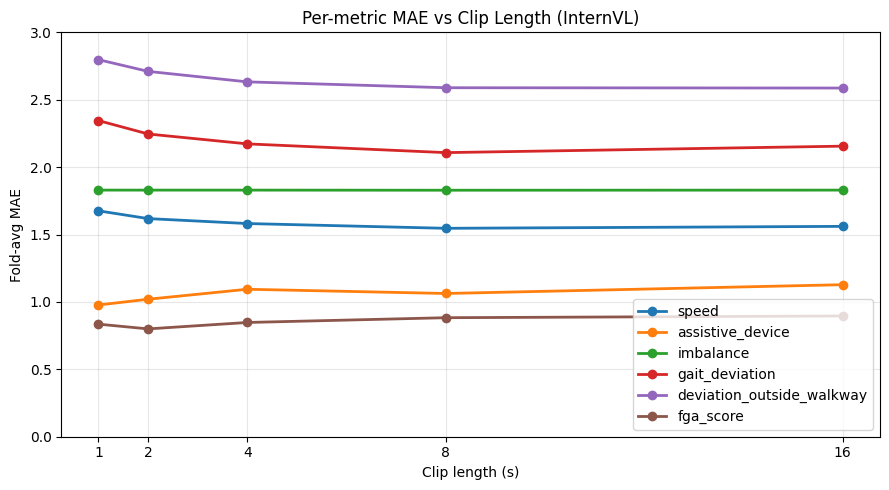

,setup_id,overall_mae,overall_mse,usable_pct
14,intern_l_noicl_therapist/clips_fps_16.0_length_1.0,1.743348,3.915528,0.978903
13,intern_l_noicl_therapist/clips_fps_8.0_length_2.0,1.703977,3.761716,0.957806
12,intern_l_noicl_therapist/clips_fps_4.0_length_4.0,1.692936,3.655336,0.978903
10,intern_l_noicl_therapist/clips_fps_2.0_length_8.0,1.669503,3.533764,0.974684
11,intern_l_noicl_therapist/clips_fps_1.0_length_16.0,1.692678,3.646724,0.978541


In [7]:
# ========= Plot 3: per-metric MAE vs clip-length (non-icl internvl_l / intern_l) =========

setup_target = "intern_l_noicl_therapist"
sub = RESULTS_DF[RESULTS_DF["setup_name"] == setup_target].copy()

if sub.empty:
    print(f"No rows for setup_name={setup_target}")
else:
    sub = sub.sort_values("length")
    lengths = sub["length"].tolist()

    plt.figure(figsize=(9, 5))
    for f in FIELDS:
        ys = [row[f] for row in sub["mae_by_field"]]
        plt.plot(lengths, ys, marker="o", linewidth=2, label=f)

    plt.xlabel("Clip length (s)")
    plt.ylabel("Fold-avg MAE")
    plt.title("Per-metric MAE vs Clip Length (InternVL)")
    plt.ylim([0, 3])
    plt.grid(alpha=0.3)
    plt.xticks(lengths)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(sub[["setup_id", "overall_mae", "overall_mse", "usable_pct"]])

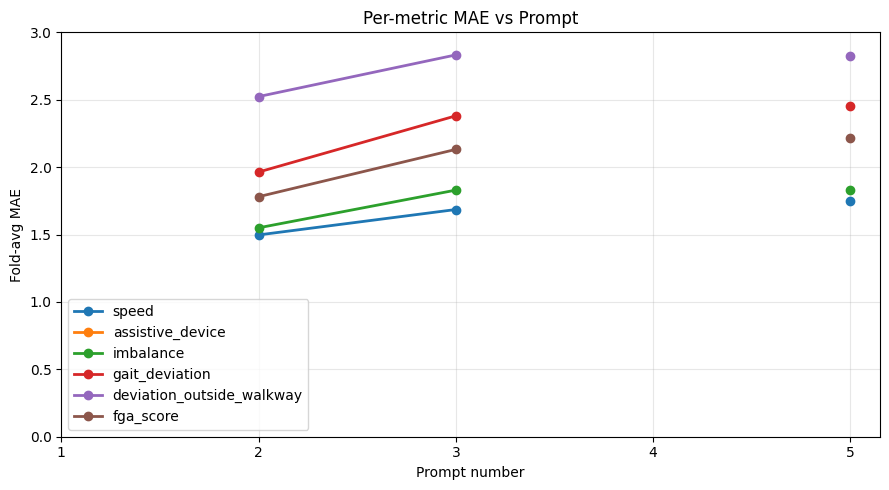

,prompt_n,setup_id,overall_mae,overall_mse,usable_pct
0,1.0,llava_l_noicl_therapist1/clips_fps_4.0_length_4.0,NaN,NaN,0.000000
1,2.0,llava_l_noicl_therapist2/clips_fps_4.0_length_4.0,2.077809,5.378448,0.995781
2,3.0,llava_l_noicl_therapist3/clips_fps_4.0_length_4.0,2.417393,6.789150,1.000000
3,4.0,llava_l_noicl_therapist4/clips_fps_4.0_length_4.0,NaN,NaN,0.000000
4,5.0,llava_l_noicl_therapist5/clips_fps_4.0_length_4.0,2.464103,6.982906,0.649789


In [8]:
# ========= Plot 4: per-metric MAE vs prompt (llava_l_noicl_therapist1-5) =========

def prompt_number_from_setup_name(name: str) -> int | None:
    m = re.match(r"^llava_l_noicl_therapist(\d+)$", name)
    return int(m.group(1)) if m else None

sub = RESULTS_DF.copy()
sub["prompt_n"] = sub["setup_name"].map(prompt_number_from_setup_name)
sub = sub[sub["prompt_n"].notna()].copy()

if sub.empty:
    print("No prompt-specific rows found for llava_l_noicl_therapist1-5")
else:
    # If multiple clip configs exist in future prompts, keep best per prompt by overall_mae.
    sub = sub.sort_values(["prompt_n", "overall_mae", "overall_mse"])
    sub = sub.groupby("prompt_n", as_index=False).first()
    sub = sub.sort_values("prompt_n")

    x = sub["prompt_n"].astype(int).tolist()

    plt.figure(figsize=(9, 5))
    for f in FIELDS:
        ys = [row[f] for row in sub["mae_by_field"]]
        plt.plot(x, ys, marker="o", linewidth=2, label=f)

    plt.xlabel("Prompt number")
    plt.ylabel("Fold-avg MAE")
    plt.ylim([0, 3])
    plt.title("Per-metric MAE vs Prompt")
    plt.grid(alpha=0.3)
    plt.xticks(x)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(sub[["prompt_n", "setup_id", "overall_mae", "overall_mse", "usable_pct"]])

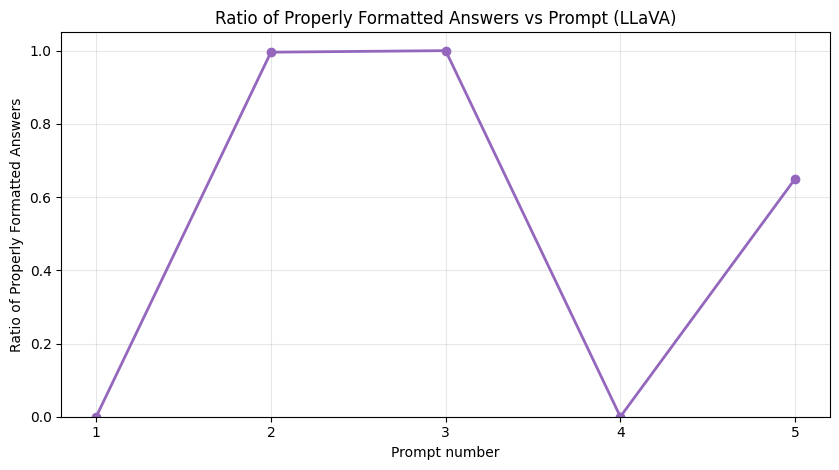

,prompt_n,setup_id,usable_pct,usable_outputs,total_outputs
0,1.0,llava_l_noicl_therapist1/clips_fps_4.0_length_4.0,0.000000,0,237
1,2.0,llava_l_noicl_therapist2/clips_fps_4.0_length_4.0,0.995781,236,237
2,3.0,llava_l_noicl_therapist3/clips_fps_4.0_length_4.0,1.000000,237,237
3,4.0,llava_l_noicl_therapist4/clips_fps_4.0_length_4.0,0.000000,0,237
4,5.0,llava_l_noicl_therapist5/clips_fps_4.0_length_4.0,0.649789,154,237


Done. Notebook is now modularized by evaluation/plot cell.


In [9]:
# ========= Plot 5: usable_pct vs prompt (llava_l_noicl_therapist1-5) =========

sub = RESULTS_DF.copy()
sub["prompt_n"] = sub["setup_name"].map(prompt_number_from_setup_name)
sub = sub[sub["prompt_n"].notna()].copy()

if sub.empty:
    print("No prompt-specific rows found for llava_l_noicl_therapist1-5")
else:
    # If multiple clip configs exist in future prompts, keep best per prompt by overall_mae.
    sub = sub.sort_values(["prompt_n", "overall_mae", "overall_mse"])
    sub = sub.groupby("prompt_n", as_index=False).first()
    sub = sub.sort_values("prompt_n")

    x = sub["prompt_n"].astype(int).tolist()
    y = sub["usable_pct"].astype(float).to_numpy()

    plt.figure(figsize=(8.5, 4.8))
    plt.plot(x, y, marker="o", linewidth=2, color="#9467BD")
    plt.ylim(0, 1.05)
    plt.xlabel("Prompt number")
    plt.ylabel("Ratio of Properly Formatted Answers")
    plt.title("Ratio of Properly Formatted Answers vs Prompt (LLaVA)")
    plt.grid(alpha=0.3)
    plt.xticks(x)
    plt.tight_layout()
    plt.show()

    display(sub[["prompt_n", "setup_id", "usable_pct", "usable_outputs", "total_outputs"]])

print("Done. Notebook is now modularized by evaluation/plot cell.")

In [10]:
# --- get best non-ICL setup (by overall MAE) ---
sub = RESULTS_DF[RESULTS_DF["setup_name"].str.contains("noicl")].copy()
sub = sub.sort_values(["overall_mae", "overall_mse"])

best = sub.iloc[0]
best_setup_id = best["setup_id"]
best_clips_root = best["clips_root"]

print("Best non-ICL setup:", best_setup_id)

# --- bootstrap FGA score CI ---
boot = bootstrap_metrics_for_clip_root(
    clips_root=best_clips_root,
    gt_map=GT_MAP,
    split_df=SPLIT_DF,
    participant_to_sample_ids=PARTICIPANT_TO_SAMPLE_IDS,
    boot_indices=BOOT_DATA,
)

fga_dist = boot["mae_by_field_dist"]["fga_score"]

mean = np.nanmean(fga_dist)
lo = np.nanpercentile(fga_dist, 2.5)
hi = np.nanpercentile(fga_dist, 97.5)

print(f"FGA MAE: {mean:.4f} (95% CI: [{lo:.4f}, {hi:.4f}])")

Best non-ICL setup: llava_l_noicl_therapist/clips_fps_2.0_length_8.0
FGA MAE: 0.6995 (95% CI: [0.5611, 0.8386])
